In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Встановлення seed для відтворюваності
torch.manual_seed(42)
np.random.seed(42)

# Пристрій (CPU або GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Використовується пристрій: {device}')

# Стиль для візуалізацій
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Використовується пристрій: cpu


In [2]:
def load_and_preprocess_data():
    # Завантаження даних
    df = pd.read_csv('WineQT.csv')
    
    print("Форма датасету:", df.shape)
    print("\nПерші рядки:")
    print(df.head())
    
    # Відокремлення ознак та міток
    df_clean = df.drop('Id', axis=1)
    X = df_clean.drop('quality', axis=1).values
    y = df_clean['quality'].values
    
    # Нормалізація ознак
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Розділення на тренувальну/валідаційну/тестову вибірки (60/20/20)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
    )
    
    # Конвертація в тензори PyTorch
    X_train_tensor = torch.FloatTensor(X_train)
    X_val_tensor = torch.FloatTensor(X_val)
    X_test_tensor = torch.FloatTensor(X_test)
    y_train_tensor = torch.LongTensor(y_train)
    y_val_tensor = torch.LongTensor(y_val)
    y_test_tensor = torch.LongTensor(y_test)
    
    print(f"\nРозміри вибірок:")
    print(f"Тренувальна: {X_train.shape[0]} зразків")
    print(f"Валідаційна: {X_val.shape[0]} зразків")
    print(f"Тестова: {X_test.shape[0]} зразків")
    print(f"Кількість ознак: {X_train.shape[1]}")
    print(f"Кількість класів: {len(np.unique(y))}")
    print(f"Класи: {sorted(np.unique(y))}")
    
    return (X_train_tensor, X_val_tensor, X_test_tensor, 
        y_train_tensor, y_val_tensor, y_test_tensor, 
        X_train, X_val, X_test, y_train, y_val, y_test, 
        scaler, X_scaled, X, y)

# Завантаження та підготовка даних
(X_train_t, X_val_t, X_test_t, 
 y_train_t, y_val_t, y_test_t,
 X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, X_scaled, X, y) = load_and_preprocess_data()

Форма датасету: (1143, 13)

Перші рядки:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5

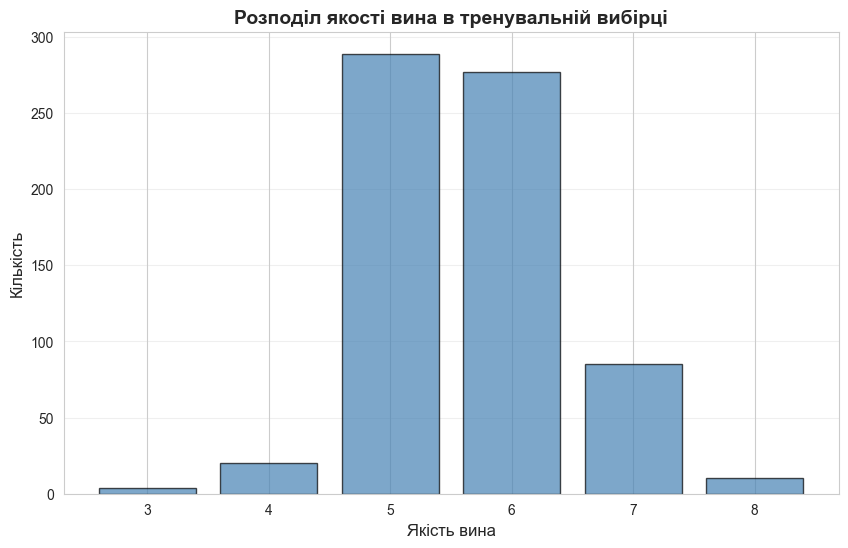

In [21]:
# Візуалізація розподілу якості
plt.figure(figsize=(10, 6))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Якість вина', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.title('Розподіл якості вина в тренувальній вибірці', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [3]:
# Збереження розмірів для подальшого використання
input_size = X_train.shape[1]
num_classes = len(np.unique(y_train))
batch_size = 32  # Для обчислення похідної в loss функції

print(f"Параметри моделі:")
print(f"  Розмір входу: {input_size}")
print(f"  Кількість класів: {num_classes}")
print(f"  Розмір батчу: {batch_size}")

Параметри моделі:
  Розмір входу: 11
  Кількість класів: 6
  Розмір батчу: 32


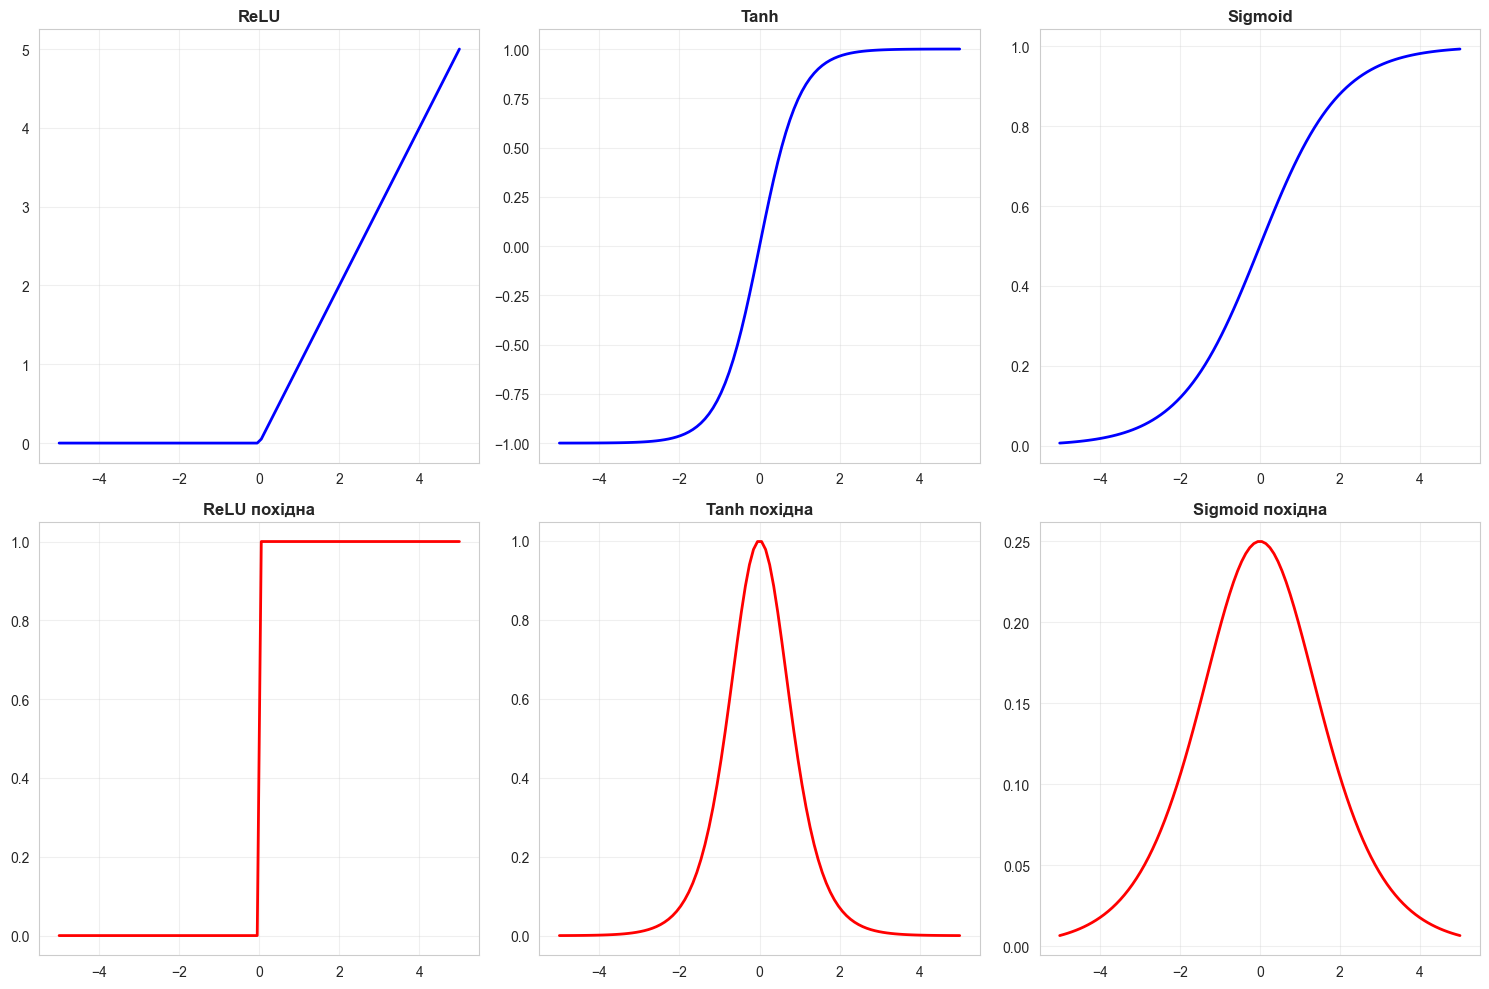

In [4]:
class ActivationFunctions:
    """Реалізація функцій активації з нуля"""
    
    @staticmethod
    def relu(x, derivative=False):
        """
        ReLU: f(x) = max(0, x)
        Похідна: 1 для x > 0, 0 для x <= 0
        """
        if derivative:
            return (x > 0).float()  # Похідна для backpropagation
        return torch.clamp(x, min=0)
    
    @staticmethod
    def tanh(x, derivative=False):
        """
        Tanh: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
        Похідна: 1 - tanh²(x)
        """
        if derivative:
            return 1 - torch.tanh(x)**2  # Похідна через тотожність
        return torch.tanh(x)
    
    @staticmethod
    def sigmoid(x, derivative=False):
        """
        Sigmoid: f(x) = 1 / (1 + e^(-x))
        Похідна: sigmoid(x) * (1 - sigmoid(x))
        """
        sig = torch.sigmoid(x)
        if derivative:
            return sig * (1 - sig)
        return sig

# Тестування функцій активації
x_test = torch.linspace(-5, 5, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# ReLU
axes[0, 0].plot(x_test.numpy(), ActivationFunctions.relu(x_test).numpy(), 'b-', linewidth=2)
axes[0, 0].set_title('ReLU', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[1, 0].plot(x_test.numpy(), ActivationFunctions.relu(x_test, derivative=True).numpy(), 'r-', linewidth=2)
axes[1, 0].set_title('ReLU похідна', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Tanh
axes[0, 1].plot(x_test.numpy(), ActivationFunctions.tanh(x_test).numpy(), 'b-', linewidth=2)
axes[0, 1].set_title('Tanh', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[1, 1].plot(x_test.numpy(), ActivationFunctions.tanh(x_test, derivative=True).numpy(), 'r-', linewidth=2)
axes[1, 1].set_title('Tanh похідна', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Sigmoid
axes[0, 2].plot(x_test.numpy(), ActivationFunctions.sigmoid(x_test).numpy(), 'b-', linewidth=2)
axes[0, 2].set_title('Sigmoid', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
axes[1, 2].plot(x_test.numpy(), ActivationFunctions.sigmoid(x_test, derivative=True).numpy(), 'r-', linewidth=2)
axes[1, 2].set_title('Sigmoid похідна', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

Training set size: 914
Test set size: 229

Features scaled successfully!
Training features shape: (914, 11)
Test features shape: (229, 11)


In [6]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoaders for batch processing
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Batch size: 32
Number of training batches: 29
Number of test batches: 8


In [32]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2):
        super(MLP, self).__init__()

        self.layer_sizes = [input_size] + hidden_sizes + [num_classes]

        layers = []

        for i in range(len(self.layer_sizes) - 1):
            in_size = self.layer_sizes[i]
            out_size = self.layer_sizes[i + 1]

            layers.append(nn.Linear(in_size, out_size))

            if i < len(self.layer_sizes) - 2:
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rate))

        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def backward(self, X, y, cache):
        """
        Зворотній прохід:
        1. Обчислюємо градієнт для вихідного шару
        2. Поширюємо градієнти назад через шари
        3. Використовуємо ланцюгове правило
        4. Оновлюємо ваги та зміщення
        """
        m = X.shape[0]
        grads = {}
        
        # Градієнти для вихідного шару
        # dLoss/dZ_output = (y_pred - y_true) / m
        A_output = cache[f'A{len(self.layer_sizes)-1}'].T  # (m, num_classes)
        dZ_output = A_output.clone()
        dZ_output[range(m), y] -= 1
        dZ_output = dZ_output.T / m  # (num_classes, m)
        
        # Градієнти для ваг вихідного шару
        A_prev = cache[f'A{len(self.layer_sizes)-2}']
        grads[f'dW{len(self.layer_sizes)-1}'] = dZ_output @ A_prev.T
        grads[f'db{len(self.layer_sizes)-1}'] = torch.sum(dZ_output, dim=1, keepdim=True)
        
        # Поширення назад через приховані шари
        dA_next = dZ_output
        W_next = self.parameters[f'W{len(self.layer_sizes)-1}']
        
        for i in range(len(self.layer_sizes) - 2, 0, -1):
            # dA = dZ_next @ W_next.T
            dA = W_next.T @ dA_next
            
            # dZ = dA * activation_derivative(Z_current)
            Z_current = cache[f'Z{i}']
            activation_func = self.activations[i-1]
            dZ = dA * activation_func(Z_current, derivative=True)
            
            # Градієнти для ваг поточного шару
            A_prev = cache[f'A{i-1}']
            grads[f'dW{i}'] = dZ @ A_prev.T
            grads[f'db{i}'] = torch.sum(dZ, dim=1, keepdim=True)
            
            # Підготовка для наступної ітерації
            dA_next = dZ
            W_next = self.parameters[f'W{i}']
        
        return grads
    
    def update_parameters(self, grads):
        """Оновлення ваг за допомогою градієнтного спуску"""
        for i in range(1, len(self.layer_sizes)):
            self.parameters[f'W{i}'] -= self.learning_rate * grads[f'dW{i}']
            self.parameters[f'b{i}'] -= self.learning_rate * grads[f'db{i}']
    
    def predict(self, X):
        """Передбачення для нових даних"""
        A_output, _ = self.forward(X, training=False)
        return torch.argmax(A_output, dim=1)
    
    def compute_loss(self, X, y):
        """Обчислення втрат"""
        A_output, _ = self.forward(X, training=False)
        # Конвертуємо в логіти для функції втрат
        # Оскільки forward повертає softmax, нам потрібні логіти
        # Для простоти, використаємо log(A_output) як наближення
        logits = torch.log(A_output + 1e-8)
        return LossFunctions.categorical_cross_entropy(logits, y)

class CustomMLP:
    def __init__(self, input_size, hidden_sizes, num_classes, learning_rate=0.01):
        self.learning_rate = learning_rate
        
        # Initialize weights
        layer_sizes = [input_size] + hidden_sizes + [num_classes]
        self.W = []
        self.b = []

        for i in range(len(layer_sizes) - 1):
            self.W.append(np.random.randn(layer_sizes[i+1], layer_sizes[i]) * 0.01)
            self.b.append(np.zeros((layer_sizes[i+1], 1)))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def softmax(self, x):
        exp = np.exp(x - np.max(x, axis=0, keepdims=True))
        return exp / np.sum(exp, axis=0, keepdims=True)

    def forward(self, X):
        cache = {}
        A = X.T
        cache["A0"] = A
        
        for i in range(len(self.W)-1):
            Z = self.W[i] @ A + self.b[i]
            A = self.relu(Z)
            cache[f"Z{i+1}"] = Z
            cache[f"A{i+1}"] = A
        
        # Output layer
        Z_out = self.W[-1] @ A + self.b[-1]
        A_out = self.softmax(Z_out)

        cache[f"Z{len(self.W)}"] = Z_out
        cache[f"A{len(self.W)}"] = A_out
        
        return A_out, cache

    def backward(self, X, y, cache):
        m = X.shape[0]
        grads_W = []
        grads_b = []

        # One-hot target
        Y = np.zeros_like(cache[f"A{len(self.W)}"])
        Y[y, np.arange(m)] = 1

        # Output gradient
        dZ = (cache[f"A{len(self.W)}"] - Y) / m

        for i in reversed(range(len(self.W))):
            A_prev = cache[f"A{i}"]
            dW = dZ @ A_prev.T
            db = np.sum(dZ, axis=1, keepdims=True)

            grads_W.insert(0, dW)
            grads_b.insert(0, db)

            if i > 0:  # propagate to previous layer
                dA_prev = self.W[i].T @ dZ
                dZ = dA_prev * self.relu_derivative(cache[f"Z{i}"])

        return grads_W, grads_b

    def update(self, grads_W, grads_b):
        for i in range(len(self.W)):
            self.W[i] -= self.learning_rate * grads_W[i]
            self.b[i] -= self.learning_rate * grads_b[i]

    def predict(self, X):
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=0)
            
# Створення моделі
layer_sizes = [input_size, 64, 32, num_classes]
activations = [ActivationFunctions.relu, ActivationFunctions.relu]

input_size = X_train.shape[1]       
hidden_sizes = [128, 64, 32]             
num_classes = len(np.unique(y))     
dropout_rate = 0.2

# Create model
model = MLP(input_size, hidden_sizes, num_classes, dropout_rate).to(device)
custom_model = CustomMLP(input_size, hidden_sizes, num_classes, learning_rate=0.01)

print("Архітектура PyTorch моделі:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

print("Архітектура власної моделі:")
for i in range(len(custom_model.W)):
    in_size = custom_model.W[i].shape[1]
    out_size = custom_model.W[i].shape[0]
    
    print(f"  Шар {i+1}: {in_size} -> {out_size}")
    print(f"    W{i+1} shape: {custom_model.W[i].shape}")
    print(f"    b{i+1} shape: {custom_model.b[i].shape}")

Архітектура PyTorch моделі:
MLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=6, bias=True)
  )
)

Total parameters: 12070
Trainable parameters: 12070
Архітектура власної моделі:
  Шар 1: 11 -> 128
    W1 shape: (128, 11)
    b1 shape: (128, 1)
  Шар 2: 128 -> 64
    W2 shape: (64, 128)
    b2 shape: (64, 1)
  Шар 3: 64 -> 32
    W3 shape: (32, 64)
    b3 shape: (32, 1)
  Шар 4: 32 -> 6
    W4 shape: (6, 32)
    b4 shape: (6, 1)


In [17]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

y_train -= y_train.min()
y_test  -= y_test.min()
y_val   -= y_val.min()

num_classes = len(np.unique(y_train))

# Training parameters
num_epochs = 100
train_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training...")
print("="*60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_x, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()
    
    # Calculate training accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Evaluation phase
    model.eval()
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total_test += batch_y.size(0)
            correct_test += (predicted == batch_y).sum().item()
    
    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Loss: {train_loss:.4f}, '
              f'Train Acc: {train_acc:.2f}%, '
              f'Test Acc: {test_acc:.2f}%')

print("="*60)
print("Training completed!")

Starting training...
Epoch [10/100], Loss: 0.9279, Train Acc: 61.27%, Test Acc: 62.88%
Epoch [20/100], Loss: 0.8686, Train Acc: 63.13%, Test Acc: 63.76%
Epoch [30/100], Loss: 0.8469, Train Acc: 64.77%, Test Acc: 61.57%
Epoch [40/100], Loss: 0.8229, Train Acc: 65.65%, Test Acc: 64.19%
Epoch [50/100], Loss: 0.7958, Train Acc: 66.52%, Test Acc: 65.07%
Epoch [60/100], Loss: 0.7458, Train Acc: 69.80%, Test Acc: 65.50%
Epoch [70/100], Loss: 0.7188, Train Acc: 69.58%, Test Acc: 64.19%
Epoch [80/100], Loss: 0.7063, Train Acc: 69.26%, Test Acc: 63.76%
Epoch [90/100], Loss: 0.6550, Train Acc: 72.87%, Test Acc: 65.94%
Epoch [100/100], Loss: 0.6672, Train Acc: 71.88%, Test Acc: 63.32%
Training completed!


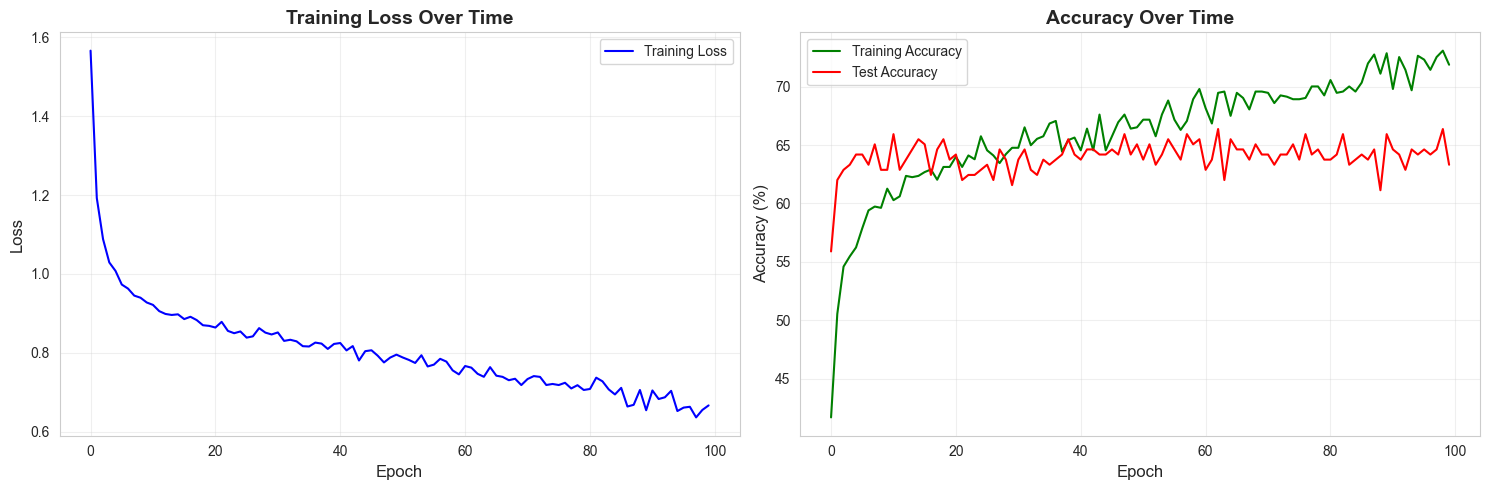

Final Training Accuracy: 71.88%
Final Test Accuracy: 63.32%


In [18]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(train_losses, label='Training Loss', color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accuracies, label='Training Accuracy', color='green')
axes[1].plot(test_accuracies, label='Test Accuracy', color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

In [19]:
# Evaluate on test set
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Convert to numpy arrays
y_pred = np.array(all_predictions)
y_true = np.array(all_labels)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Test Accuracy: 0.6332 (63.32%)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         7
           2       0.67      0.82      0.74        97
           3       0.60      0.55      0.58        92
           4       0.56      0.48      0.52        29
           5       0.00      0.00      0.00         3

    accuracy                           0.63       229
   macro avg       0.31      0.31      0.31       229
weighted avg       0.60      0.63      0.61       229



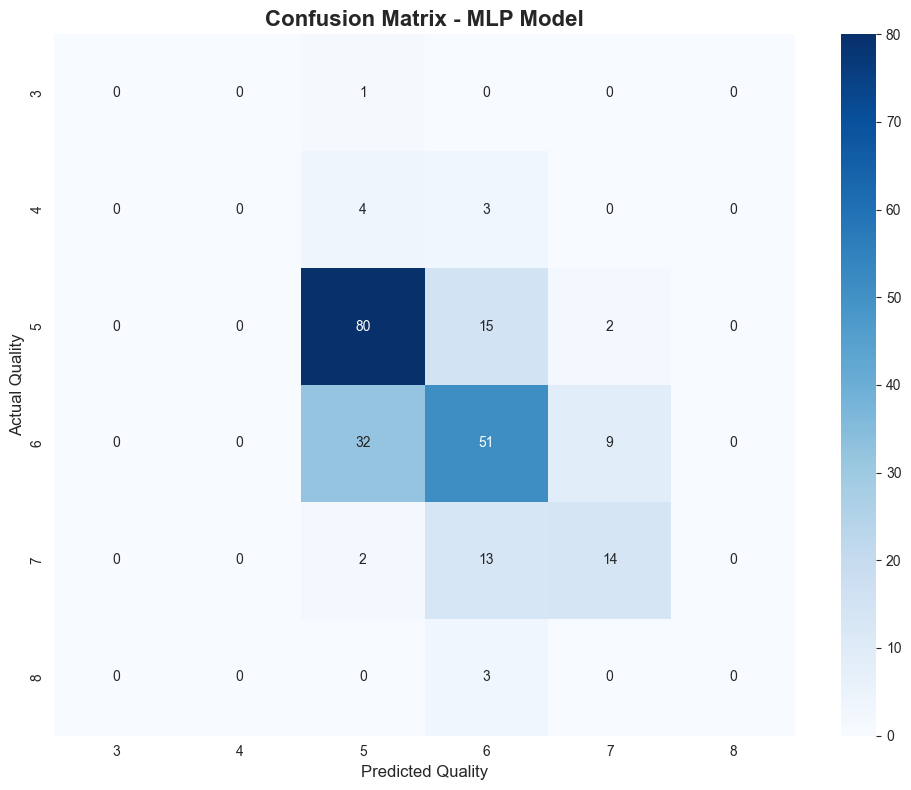

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y)),
            yticklabels=sorted(np.unique(y)))
plt.title('Confusion Matrix - MLP Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Quality', fontsize=12)
plt.ylabel('Actual Quality', fontsize=12)
plt.tight_layout()
plt.show()

Epoch [10/100], Loss: 1.4518, Train Acc: 42.23%, Test Acc: 42.36%
Epoch [20/100], Loss: 1.3173, Train Acc: 42.23%, Test Acc: 42.36%
Epoch [30/100], Loss: 1.2576, Train Acc: 42.23%, Test Acc: 42.36%
Epoch [40/100], Loss: 1.1940, Train Acc: 42.23%, Test Acc: 42.36%
Epoch [50/100], Loss: 1.1663, Train Acc: 44.75%, Test Acc: 44.10%
Epoch [60/100], Loss: 1.1630, Train Acc: 44.53%, Test Acc: 46.72%
Epoch [70/100], Loss: 1.1593, Train Acc: 46.28%, Test Acc: 46.72%
Epoch [80/100], Loss: 1.1573, Train Acc: 46.06%, Test Acc: 46.72%
Epoch [90/100], Loss: 1.1566, Train Acc: 46.06%, Test Acc: 50.22%
Epoch [100/100], Loss: 1.1571, Train Acc: 46.06%, Test Acc: 49.78%


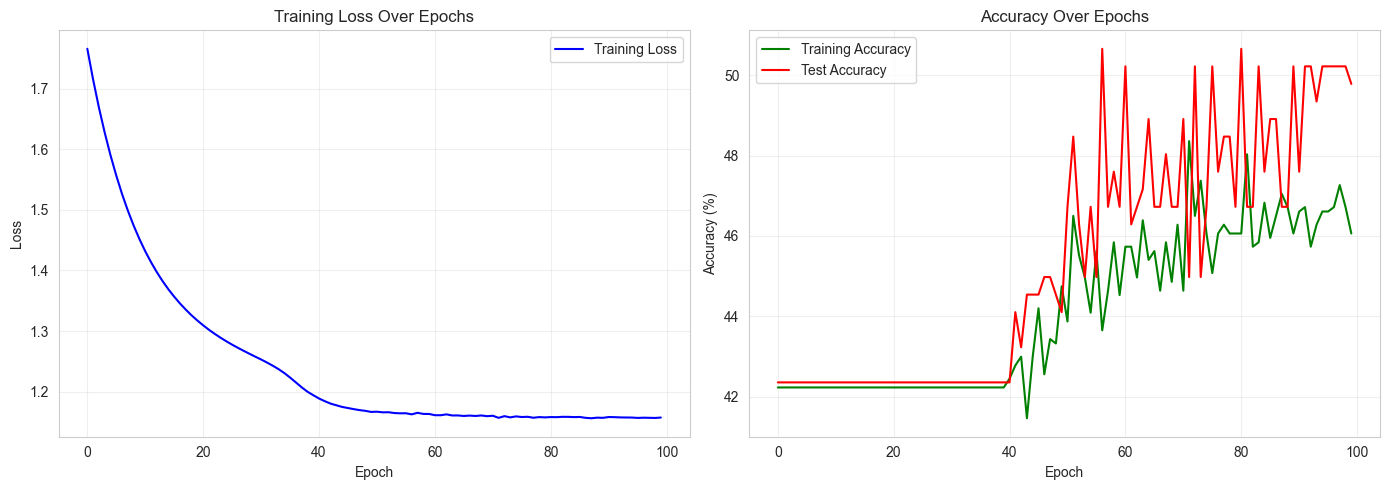

Final Training Accuracy: 46.06%
Final Test Accuracy: 49.78%


In [33]:
def cross_entropy_loss(probs, y):
    m = y.shape[0]
    log_likelihood = -np.log(probs[y, np.arange(m)] + 1e-15)
    loss = np.sum(log_likelihood) / m
    return loss

def accuracy(y_pred, y_true):
    return np.mean(y_pred == y_true) * 100

def train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    n_samples = X_train.shape[0]
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]

        running_loss = 0
        correct = 0
        total = 0

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            batch_x = X_train_shuffled[start:end]
            batch_y = y_train_shuffled[start:end]

            probs, cache = model.forward(batch_x)
            loss = cross_entropy_loss(probs, batch_y)
            grads_W, grads_b = model.backward(batch_x, batch_y, cache)
            model.update(grads_W, grads_b)

            running_loss += loss * batch_x.shape[0]

            preds = np.argmax(probs, axis=0)
            correct += np.sum(preds == batch_y)
            total += batch_x.shape[0]

        train_loss = running_loss / n_samples
        train_acc = correct / total * 100
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        test_preds = model.predict(X_test)
        test_acc = accuracy(test_preds, y_test)
        test_accuracies.append(test_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_losses, label='Training Loss', color='blue')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss Over Epochs')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(train_accuracies, label='Training Accuracy', color='green')
    axes[1].plot(test_accuracies, label='Test Accuracy', color='red')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy Over Epochs')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")

train_model(custom_model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32)

Test Accuracy: 0.4978 (49.78%)

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         7
           2       0.57      0.53      0.55        97
           3       0.45      0.68      0.54        92
           4       0.00      0.00      0.00        29
           5       0.00      0.00      0.00         3

    accuracy                           0.50       229
   macro avg       0.17      0.20      0.18       229
weighted avg       0.42      0.50      0.45       229



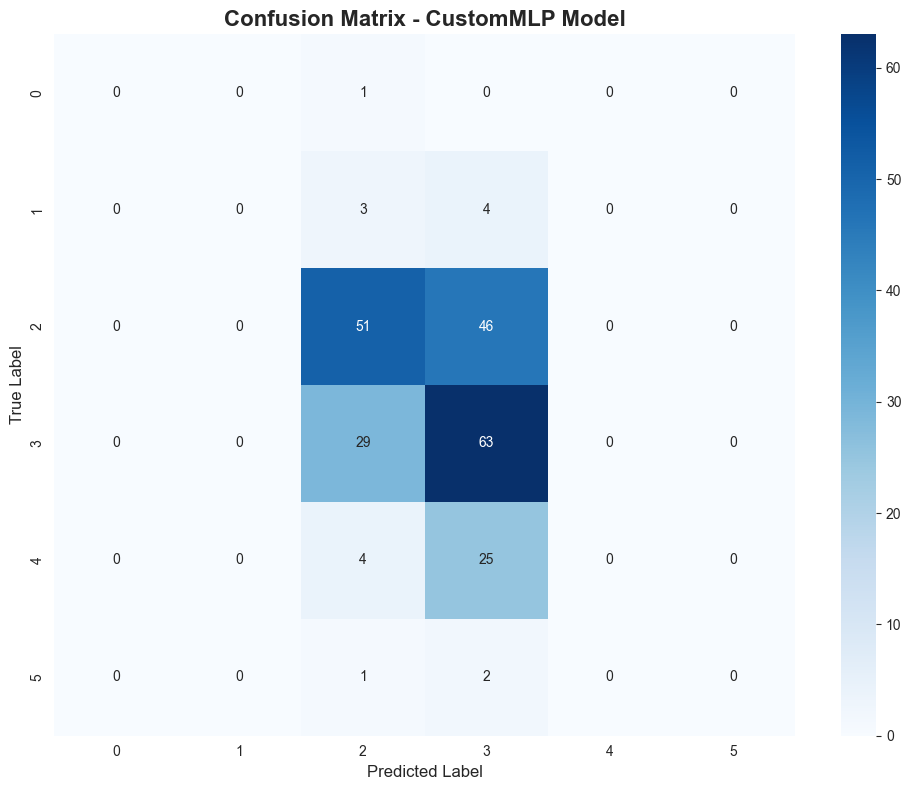

In [37]:
y_pred = custom_model.predict(X_test)
y_true = y_test

# Обчислення точності
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Звіт класифікації
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Матриця плутанини
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y_true)),
            yticklabels=sorted(np.unique(y_true)))
plt.title('Confusion Matrix - CustomMLP Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#Висновок: Кастомна MLP реалізація виявилися менш точною, як і очікувалося, ніж PyTorch MLP (49.78% vs. 63.32).

#Тренування кастомної моделі, неоікувано, зайняло менше часу ніж PyTorch.